## Counterfactuals generation for C2019-05 Fuel Tank Filter 

Sneak peak of the project

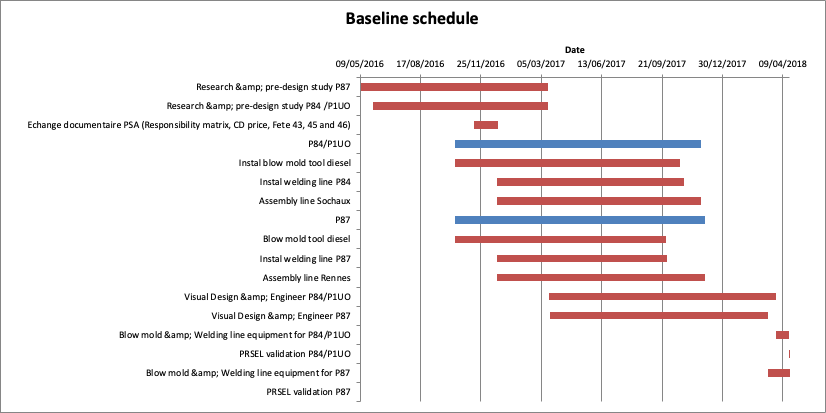
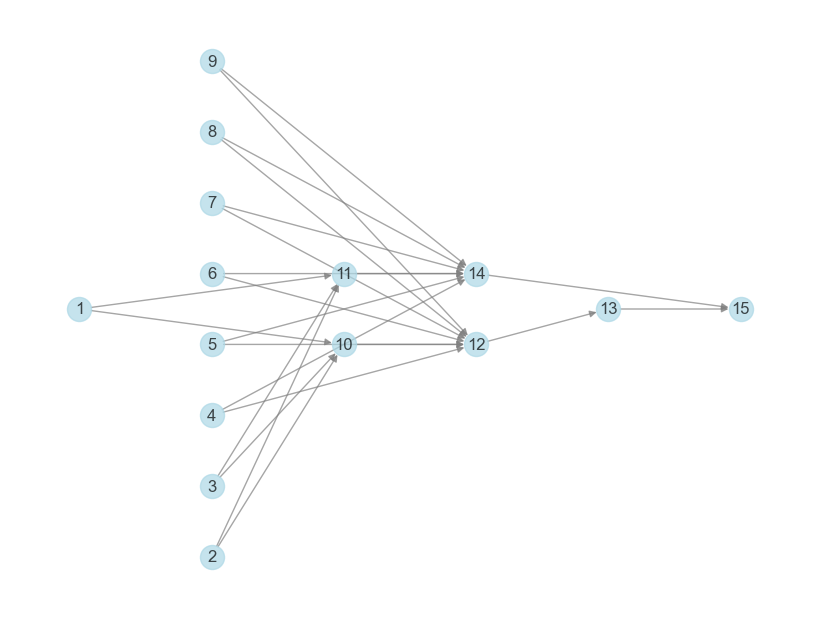
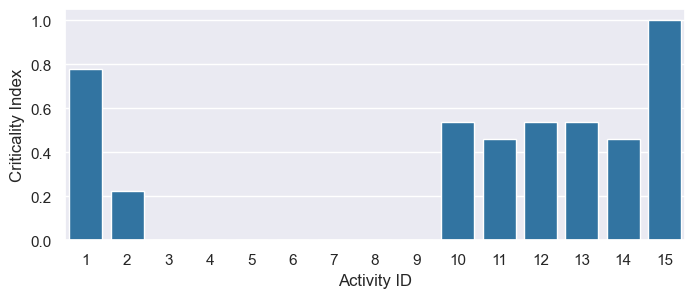

### **Flujo de Actividades del Proyecto**  

#### **1. Investigación y Pre-diseño**  
1. **Research & pre-design study P87** – Análisis técnico y económico del diseño P87.  
2. **Research & pre-design study P84/P1UO** – Evaluación del diseño P84/P1UO.  
3. **Echange documentaire PSA** – Gestión documental y coordinación entre equipos.  

#### **2. Instalaciones de Producción**  
4. **Molde de soplado diésel** – Instalación del equipo para fabricar tanques de combustible.  
5. **Línea de soldadura P84** – Implementación de la línea de soldadura del modelo P84.  
6. **Línea de ensamblaje Sochaux** – Habilitación de la línea de ensamblaje en Sochaux.  
7. **Molde de soplado P87** – Instalación del equipo para la producción del modelo P87.  
8. **Línea de soldadura P87** – Implementación de la línea de soldadura del modelo P87.  
9. **Línea de ensamblaje Rennes** – Habilitación de la línea de ensamblaje en Rennes.  

#### **3. Diseño Visual e Ingeniería**  
10. **Visual Design & Engineer P84/P1UO** – Desarrollo y validación técnica del diseño P84/P1UO.  
11. **Visual Design & Engineer P87** – Desarrollo y validación técnica del diseño P87.  

#### **4. Validaciones Finales y Pruebas**  
12. **Molde de soplado & línea de soldadura P84/P1UO** – Pruebas de producción para el modelo P84/P1UO.  
13. **Validación PRSEL P84/P1UO** – Certificación final del modelo P84/P1UO.  
14. **Molde de soplado & línea de soldadura P87** – Pruebas de producción para el modelo P87.  
15. **Validación PRSEL P87** – Certificación final del modelo P87.  

El proyecto sigue un flujo secuencial: **investigación → implementación → diseño final → validación**, asegurando la viabilidad del producto antes de la producción en serie.  


In [1]:
import numpy as np #!pip install --upgrade numpy==1.26.4
import pandas as pd
import random


from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import RandomSearch

import dice_ml
from dice_ml.utils import helpers  # helper functions

from IPython.core.display import display
import joblib



#set random seed
my_seed=42
np.random.seed(my_seed)

#diable warning printing
import warnings
warnings.filterwarnings('ignore')

/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_47352/2437478850.py:20: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display


In [2]:
# Normalize the dataset to improve the performance of the classifiers

def normalize_dataframe(df, feature_range=(0, 1)):
    """
    Normaliza un DataFrame de pandas utilizando MinMaxScaler.

    Args:
        df (pd.DataFrame): DataFrame a normalizar.
        feature_range (tuple): Rango de valores para la normalización (por defecto (0, 1)).

    Returns:
        pd.DataFrame: DataFrame normalizado.
        MinMaxScaler: Escalador utilizado para la normalización.
    """
    scaler = MinMaxScaler(feature_range=feature_range)
    normalized_data = scaler.fit_transform(df)
    normalized_df = pd.DataFrame(normalized_data, columns=df.columns, index=df.index)
    return normalized_df, scaler

def denormalize_dataframe(normalized_df, scaler):
    """
    Desnormaliza un DataFrame de pandas utilizando un MinMaxScaler previamente ajustado.

    Args:
        normalized_df (pd.DataFrame): DataFrame normalizado.
        scaler (MinMaxScaler): Escalador utilizado para la normalización.

    Returns:
        pd.DataFrame: DataFrame desnormalizado.
    """
    denormalized_data = scaler.inverse_transform(normalized_df)
    denormalized_df = pd.DataFrame(denormalized_data, columns=normalized_df.columns, index=normalized_df.index)
    return denormalized_df


In [3]:
def analyze_counterfactuals(original_instance, cf_results, scaler, true_labels=None):
    """
    Analyzes and compares original instances with generated counterfactuals (CFs).
    
    Args:
        original_instance (pd.DataFrame): Original input instance (e.g., X_test[1:2])
        cf_results (object): CF generator results object (contains final_cfs_df)
        scaler (object): Scaler used for normalization
        true_labels (pd.DataFrame, optional): True labels if available (e.g., y_test[1:2])
        
    Returns:
        tuple: (denormalized_original, denormalized_cfs, comparison_df)
    """
    # Denormalize original instance
    denormalized_original = denormalize_dataframe(original_instance, scaler)
    
    # Combine with true labels if provided
    if true_labels is not None:
        original_combined = pd.concat([
            denormalized_original.reset_index(drop=True),
            true_labels.reset_index(drop=True)
        ], axis=1)
        print("\nOriginal instance (denormalized):")
        display(original_combined)
    else:
        print("\nOriginal instance (denormalized):")
        display(denormalized_original)
    
    # Denormalize counterfactuals
    cf_data = cf_results.cf_examples_list[0].final_cfs_df
    denormalized_cfs = denormalize_dataframe(cf_data.drop(columns=['delay']), scaler)
    delay_column = cf_data['delay'].reset_index(drop=True)
    denormalized_cfs = denormalized_cfs.reset_index(drop=True)

    denormalized_cfs['delay'] = delay_column.round() # DiCE round the class in display mode here https://interpret.ml/DiCE/_modules/dice_ml/diverse_counterfactuals.html#CounterfactualExamples         if model_type == ModelTypes.Classifier:
    denormalized_cfs.index = range(1, len(denormalized_cfs) + 1) 
    
    # Format counterfactuals display
    print("\nDiverse Counterfactual set (new outcome: {})".format(denormalized_cfs['delay'].iloc[0]))
    
    # Create formatted display
    formatted_cfs = denormalized_cfs.copy()
    
    # Replace values with '-' when they match the original instance (except 'delay')
    original_values = denormalized_original.iloc[0].to_dict()
    for col in formatted_cfs.columns:
        if col != 'delay':
            formatted_cfs[col] = formatted_cfs.apply(
                lambda row: '-' if np.isclose(row[col], original_values.get(col, np.nan)) else row[col],
                axis=1
            )
    
    # Display with all columns visible
    pd.set_option('display.max_columns', None)
    display(formatted_cfs)
    
    # Create comparison DataFrame with percentage changes
    comparison_df = denormalized_cfs.copy()
    for col in denormalized_original.columns:
        original_val = denormalized_original[col].values[0]
        comparison_df[f"{col}_change_%"] = (
            (denormalized_cfs[col] - original_val) / original_val
        ) * 100
    
    # Keep only percentage change columns
    comparison_df = comparison_df[[
        col for col in comparison_df.columns 
        if '_change_%' in col
    ]].fillna(0)
    
    # Style the comparison
    styled_comparison = comparison_df.style.applymap(
        lambda x: "color: white;" if x != 0 else "color: grey;"
    ).format("{:.2f}")
    
    print("\nComparison between original and counterfactuals (% change):")
    display(styled_comparison)
    
    return denormalized_original, denormalized_cfs, comparison_df

In [ ]:
# Data set load
data=pd.read_csv('../sim_data/C201905_counterfactuals/simulation_C201905_counterfactuals__ev0.1812.csv',index_col=0)


# Create a target variable, 'delay' and remove unnecessary columns
data['delay']=(data['actual_duration']>data['baseline_duration'])*1
data.drop(columns=['actual_duration','baseline_duration','critical_path'],inplace=True)
# Sort the columns
columns_sorted = sorted(data.columns, key=lambda x: int(x.replace('duration', '')) if 'duration' in x else float('inf'))
data = data[columns_sorted]
data.head(2)

,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1738.595774,1967.122966,256.504345,2186.408241,1723.181771,1898.648645,1795.289433,1599.760892,2224.382275,2489.048379,2124.279759,139.271436,8.498099,234.542254,7.655393,1
1,1717.864331,1881.352898,266.048082,2324.022291,1849.728508,2083.309016,1839.782891,1593.929687,2323.598219,2279.745524,2334.495021,145.448900,8.235859,238.908956,8.357302,1


In [5]:
data_to_normalize = data.iloc[:, :-1]  # Select all columns except the last one
normalized_data, my_scaler = normalize_dataframe(data_to_normalize)
data = pd.concat([normalized_data, data.iloc[:, -1]], axis=1)  # Combine normalized data with the last column


# Split the dataset into features and class
X = data.drop(columns=['delay'])
y = data['delay']

data.head(2)

,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.751643,0.821171,0.653332,0.547362,0.393468,0.432562,0.715566,0.442461,0.804429,0.891496,0.551165,0.700622,0.641918,0.698465,0.380315,1
1,0.675055,0.594889,0.759338,0.713173,0.582989,0.679778,0.789338,0.432862,0.938094,0.637179,0.819892,0.830761,0.556337,0.752252,0.604439,1


## Query instance and data model for DiCE

In [6]:
query_instance = X.loc[[11030]] # X[inicio:fin] df.loc[[index]] mantener formato 2D de una fila
class_of_query_instance = y.loc[[11030]]
print(data.loc[[11030]])

 #construct a data object for DiCE. 
d = dice_ml.Data(dataframe=data, continuous_features=['duration1', 'duration2', 'duration3', 'duration4', 'duration5', 
                                                      'duration6', 'duration7', 'duration8', 'duration9', 'duration10', 
                                                      'duration11', 'duration12', 'duration13', 'duration14', 'duration15'], 
                 outcome_name='delay')

       duration1  duration2  duration3  duration4  duration5  duration6  \
11030   0.585886   0.607324   0.664474   0.748976   0.634275   0.755783   

       duration7  duration8  duration9  duration10  duration11  duration12  \
11030    0.73114    0.65732   0.652216    0.694802     0.77068    0.690896   

       duration13  duration14  duration15  delay  
11030    0.678432    0.508539    0.805898      1  


In [7]:
# Create a dataframe for the comparison of results
comparison_df = pd.DataFrame(columns=[
    'duration1', 'duration2', 'duration3', 'duration4', 'duration5', 
    'duration6', 'duration7', 'duration8', 'duration9', 'duration10', 
    'duration11', 'duration12', 'duration13', 'duration14', 'duration15', 
    'delay', 'subrogate_model', 'method', 'proximity', 'diversity', 'sparsity'
])

## Modelo con TensorFLow

In [ ]:
tf_model = keras.models.load_model('../models/tf_best_model.keras')
# initialize the model for DiCE
m_tf = dice_ml.Model(model=tf_model, backend="TF2") 

#### CFs with randomized sampling method

In [9]:
# initiate the DiCE explainer, which needs a dataset and a model. 
tf_random = dice_ml.Dice(data_interface=d, model_interface=m_tf, method="random")

CFs_tf_random = tf_random.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_tf_random.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:13<00:00, 13.55s/it]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,-,-,-,-,-,-,-,-,-,-,0.40914379,-,-,-,-,0.0
1,-,0.10142083,-,-,-,-,-,-,-,-,-,-,-,-,0.2086676,0.0
2,-,0.40414033,-,-,-,-,-,-,0.17110248,-,-,-,-,-,-,0.0
3,-,0.04821204,-,-,-,0.50592581,-,-,-,-,-,-,-,-,-,0.0
4,-,-,0.14071153,-,-,-,-,-,-,-,0.2628807,-,-,-,-,0.0
5,-,0.32703316,-,-,-,-,0.7140579600005025,-,-,-,-,-,-,-,-,0.0
6,-,0.00638587,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
7,0.13688563,0.440199,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
8,-,0.24667887,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
9,-,0.48296888,-,-,-,-,-,-,-,-,0.35688867,-,-,-,-,0.0


In [10]:
# Analyze the counterfactuals

original, cfs, comparison = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_tf_random,
    scaler=my_scaler,
    true_labels=class_of_query_instance
)

# Save results in a DataFrame for comparison
cfs["subrogate_model"] = "TensorFLow"
cfs["method"] = "random"
cfs["proximity"] = 0.5
cfs["diversity"] = 1
cfs["sparsity"] = "0.1 linear"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs)], ignore_index=True)



Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,-,-,-,-,-,-,-,-,-,-,2013.182099,-,-,-,-,0
2,-,1694.308385,-,-,-,-,-,-,-,-,-,-,-,-,7.117832,0
3,-,1809.051378,-,-,-,-,-,-,1754.282665,-,-,-,-,-,-,0
4,-,1674.140092,-,-,-,1953.448719,-,-,-,-,-,-,-,-,-,0
5,-,-,210.352759,-,-,-,-,-,-,-,1898.765933,-,-,-,-,0
6,-,1779.824627,-,-,-,-,1794.319677,-,-,-,-,-,-,-,-,0
7,-,1658.286273,-,-,-,-,-,-,-,-,-,-,-,-,-,0
8,1572.187384,1822.71908,-,-,-,-,-,-,-,-,-,-,-,-,-,0
9,-,1749.367086,-,-,-,-,-,-,-,-,-,-,-,-,-,0
10,-,1838.930602,-,-,-,-,-,-,-,-,1972.304866,-,-,-,-,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-12.32,0.00,0.00,0.00,0.00
2,0.00,-10.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-20.81
3,0.00,-4.08,0.00,0.00,0.00,0.00,0.00,0.00,-16.91,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,-11.24,0.00,0.00,0.00,-8.72,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,-18.31,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-17.30,0.00,0.00,0.00,0.00
6,0.00,-5.63,0.00,0.00,0.00,0.00,-0.57,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,-12.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,-7.18,-3.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,0.00,-7.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
10,0.00,-2.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-14.10,0.00,0.00,0.00,0.00


#### CFs con Gradient based Method. Mothilal et al. (2020)


In [11]:
# initiate the DiCE explainer, which needs a dataset and a model. 
tf_gradient = dice_ml.Dice(data_interface=d, model_interface=m_tf, method="gradient")

CFs_tf_gradient = tf_gradient.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_tf_gradient.visualize_as_dataframe(show_only_changes=True)

Diverse Counterfactuals found! total time taken: 01 min 04 sec
Query instance (original outcome : 0.9700000286102295)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755783,0.73114,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,0.97



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.7640422582626343,0.0,0.6405706239705342,0.7234963774681091,0.619727714157607,0.7394884062772054,0.7147111726765889,0.687908947467804,0.6592154668802959,0.7642422318458557,0.28067219257354736,0.7112549709315044,0.678083062171936,0.5203981565470439,0.8026929030413132,0.0
1,0.5890418457026225,0.2808394730091095,0.7073052525520325,0.7390296293263692,0.6361665891642314,0.74864511022618,0.8785939812660217,0.6022583842277527,0.7522913813591003,0.6986230181689006,0.6702697277069092,0.34317490458488464,0.6629633141522664,0.5284989046091777,0.8315740823745728,0.0
2,0.38571569323539734,0.2888592481613159,0.6663094924921733,0.7631272243494731,0.6489055918688518,0.6317672729492188,0.7571586536402446,0.7093358039855957,0.6467533541684407,0.10967367142438889,0.37223342061042786,0.4935755729675293,0.6798907088274699,0.504924817181136,0.8096501102452773,0.0
3,0.5998291539187175,0.5998723340993184,0.6672065423960429,0.7661557959551555,0.637523786925767,0.7384086085324544,0.7036502957344055,0.6200095415115356,0.6607150005335551,0.45690926909446716,0.40465468168258667,0.6883041096692342,0.6747842861180562,0.5176909731859904,0.296175092458725,0.0
4,0.6045019792551738,0.6838119626045227,0.679530041121934,0.7467585636143941,0.6457526253695232,0.755413830280304,0.71719340810826,0.6509932709698933,0.5983483791351318,0.050514280796051025,0.15738418698310852,0.6950259970659953,0.6864922808642131,0.525738971137498,0.8563923835754395,0.0
5,0.569032712078597,0.46510669589042664,0.6840970086092693,0.793283998966217,0.7875440716743469,0.7488398982053059,0.6601088643074036,0.6699629591936809,0.2960929572582245,0.6952844858169556,0.5762662291526794,0.694245355033372,0.7058671116828918,0.5093423128128052,0.8125805726056594,0.0
6,0.596223966979478,0.37943002581596375,0.7923767566680908,0.7501351403231364,0.5474791526794434,0.9967236518859863,0.7385305928225261,0.7019293904304504,0.6521037220954895,0.3103977143764496,0.33231472969055176,0.7083688544268352,0.691108422183488,0.20407342910766602,0.8116069903378982,0.0
7,0.581459446049239,0.5216655135154724,0.2897779643535614,0.7179390788078308,0.6211217475896138,0.7740102576250774,0.7302103638648987,0.6530496908192891,0.6375346017842549,0.49551084637641907,0.46434321999549866,0.5766500234603882,0.6452341675758362,0.5965238809585571,0.7490603923797607,0.0
8,0.592561857604478,0.3521084189414978,0.628950834274292,0.6555458307266235,0.6541864441866618,0.7880217432975769,0.7403979467386943,0.5017015933990479,0.6972128748893738,0.26483026146888733,0.7189509868621826,0.6807109547620076,0.8679113984107971,0.4993950558661888,0.817366885185768,0.0
9,0.5781950784688252,0.18761475384235382,0.6711439656252605,0.7428761554723042,0.6450255679125529,0.7619236873621684,0.7438975738520366,0.6527405811314839,0.6423172188763875,0.6301403045654297,0.820404052734375,0.8199994564056396,0.6523839235305786,0.18504835665225983,0.802593184470604,0.0


In [12]:
# Analyze the counterfactuals

original, cfs2, comparison2 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_tf_gradient,
    scaler=my_scaler,
    true_labels=class_of_query_instance
)

# Save results in a DataFrame for comparison
cfs2["subrogate_model"] = "TensorFLow"
cfs2["method"] = "gradient"
cfs2["proximity"] = 0.5
cfs2["diversity"] = 1
cfs2["sparsity"] = "0.1 linear"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs2)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1741.952148,1655.865723,255.346390,2332.590088,1874.192505,2127.835693,1794.713623,1748.857422,2116.669189,2384.318848,1912.683594,139.780899,8.608915,220.093857,8.975060,0.0
2,1694.608398,1762.315308,261.363525,2345.398682,1885.302612,2134.675293,1893.615234,1696.829224,2185.682373,2330.396484,2217.451172,122.304039,8.562279,220.751526,9.068642,0.0
3,1639.543091,1765.355103,257.681671,2365.564453,1893.808594,2047.447266,1820.435303,1761.873169,2107.270264,1845.609985,1984.308472,129.443283,8.614760,218.821411,9.003112,0.0
4,1697.528442,1883.203857,257.762451,2368.078125,1886.208740,2127.029053,1788.102905,1707.612183,2117.781982,2131.384277,2009.670410,138.681961,8.598501,219.874069,7.391887,0.0
5,1698.793335,1915.058228,258.871918,2351.813232,1891.703369,2139.806152,1796.210815,1726.372314,2071.414795,1796.921997,1816.239868,139.010544,8.634989,220.527466,9.146367,0.0
6,1689.137939,1832.160156,259.283081,2390.510010,1986.313232,2134.820801,1761.842041,1738.016968,1847.059448,2327.566650,2143.915771,138.973480,8.694052,219.188171,9.012289,0.0
7,1696.552612,1799.685181,269.022583,2354.781738,1826.017700,2320.054688,1809.200195,1757.374023,2111.315918,2010.805542,1953.081543,139.643906,8.649135,194.404663,9.009240,0.0
8,1692.501831,1853.598145,223.773300,2327.977783,1875.123291,2153.771484,1804.121826,1727.621582,2100.427490,2163.153320,2056.362549,133.386688,8.508259,226.266068,8.810225,0.0
9,1695.561279,1789.329102,254.309250,2276.194580,1897.334839,2164.162842,1810.326416,1635.746216,2144.799072,1973.303589,2255.532715,138.321533,9.190592,218.372482,9.027280,0.0
10,1691.618164,1726.979370,258.116913,2348.591064,1891.217896,2144.743408,1812.437256,1727.433716,2103.977295,2273.953125,2334.895752,144.938065,8.530168,192.860092,8.974748,0.0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,2.85,-12.21,-0.84,-0.90,-0.52,-0.57,-0.55,1.07,0.25,2.46,-16.69,0.70,-0.01,0.44,-0.15
2,0.05,-6.56,1.50,-0.35,0.07,-0.25,4.93,-1.93,3.52,0.14,-3.42,-11.89,-0.55,0.74,0.89
3,-3.20,-6.40,0.07,0.50,0.52,-4.33,0.87,1.83,-0.20,-20.69,-13.58,-6.75,0.06,-0.14,0.17
4,0.22,-0.15,0.10,0.61,0.12,-0.61,-0.92,-1.31,0.30,-8.41,-12.47,-0.09,-0.13,0.34,-17.76
5,0.30,1.54,0.53,-0.08,0.41,-0.01,-0.47,-0.23,-1.89,-22.79,-20.90,0.14,0.29,0.64,1.76
6,-0.27,-2.86,0.69,1.56,5.43,-0.25,-2.37,0.45,-12.52,0.02,-6.62,0.12,0.98,0.03,0.27
7,0.17,-4.58,4.47,0.04,-3.08,8.41,0.25,1.57,-0.00,-13.59,-14.94,0.60,0.45,-11.28,0.23
8,-0.07,-1.72,-13.10,-1.09,-0.47,0.64,-0.03,-0.15,-0.52,-7.05,-10.44,-3.91,-1.18,3.26,-1.98
9,0.11,-5.13,-1.24,-3.29,0.71,1.13,0.31,-5.46,1.58,-15.21,-1.76,-0.35,6.74,-0.34,0.43
10,-0.12,-8.43,0.24,-0.22,0.38,0.22,0.43,-0.16,-0.35,-2.29,1.69,4.41,-0.93,-11.99,-0.15


## Control sparsity

The posthoc_sparsity_algorithm parameter accepts two options: "linear"(default) or "binary" 
InterpretML
. The linear search greedily moves each continuous feature of the counterfactual back toward its original value in fixed increments until the model’s prediction flips, whereas the binary search bisects the interval between the counterfactual and the original feature value—halving the range at each step—making it more efficient when feature ranges are large and when a monotonic relationship with the output can be assumed.

The posthoc_sparsity_param is a non‐negative float (default = 0.1) that controls the strength of the post‐hoc sparsity enhancement:

Values closer to 0 impose minimal additional sparsity pressure, leaving most feature changes intact.

Values closer to 1 aggressively retract changes toward the original instance, yielding sparser counterfactuals.

In [13]:
CFs_tf_gradient_sw1_bin = tf_gradient.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite", posthoc_sparsity_param=1, posthoc_sparsity_algorithm='binary')

# Parece que sólo muestra cambios mayores al 5%
CFs_tf_gradient_sw1_bin.visualize_as_dataframe(show_only_changes=True)

Diverse Counterfactuals found! total time taken: 01 min 03 sec
Query instance (original outcome : 0.9700000286102295)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755783,0.73114,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,0.97



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.7640422582626343,0.0,-,-,-,-,-,-,-,-,0.28067219257354736,-,-,-,-,0.0
1,-,0.2808394730091095,-,-,-,-,0.8785939812660217,-,-,-,-,0.34317490458488464,-,-,-,0.0
2,0.38571569323539734,0.2888592481613159,-,-,-,-,-,-,-,0.10967367142438889,0.37223342061042786,0.4935755729675293,-,-,-,0.0
3,-,-,-,-,-,-,-,-,-,0.45690926909446716,0.40465468168258667,-,-,-,0.296175092458725,0.0
4,-,-,-,-,-,-,-,-,-,0.050514280796051025,0.15738418698310852,-,-,-,-,0.0
5,-,0.46510669589042664,-,-,0.7875440716743469,-,-,-,0.2960929572582245,-,0.5762662291526794,-,-,-,-,0.0
6,-,0.37943002581596375,-,-,-,0.9967236518859863,-,-,-,0.3103977143764496,0.33231472969055176,-,-,0.20407342910766602,-,0.0
7,-,-,0.2897779643535614,-,-,-,-,-,-,0.49551084637641907,0.46434321999549866,-,-,-,-,0.0
8,-,0.3521084189414978,-,-,-,-,-,0.5017015933990479,-,0.26483026146888733,-,-,0.8679113984107971,-,-,0.0
9,-,0.18761475384235382,-,-,-,-,-,-,-,-,-,-,-,0.18504835665225983,-,0.0


In [14]:
# Analyze the counterfactuals

original, cfs2_sw1, comparison2_sw1 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_tf_gradient_sw1_bin,
    scaler=my_scaler,
    true_labels=class_of_query_instance
)

# Save results in a DataFrame for comparison
cfs2_sw1["subrogate_model"] = "TensorFLow"
cfs2_sw1["method"] = "gradient"
cfs2_sw1["proximity"] = 0.5
cfs2_sw1["diversity"] = 1
cfs2_sw1["sparsity"] = "1 binary"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs2_sw1)], ignore_index=True)



Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1741.952148,1655.865723,255.346390,2332.590088,1874.192505,2127.835693,1794.713623,1748.857422,2116.669189,2384.318848,1912.683594,139.780899,8.608915,220.093857,8.975060,0.0
2,1694.608398,1762.315308,261.363525,2345.398682,1885.302612,2134.675293,1893.615234,1696.829224,2185.682373,2330.396484,2217.451172,122.304039,8.562279,220.751526,9.068642,0.0
3,1639.543091,1765.355103,257.681671,2365.564453,1893.808594,2047.447266,1820.435303,1761.873169,2107.270264,1845.609985,1984.308472,129.443283,8.614760,218.821411,9.003112,0.0
4,1697.528442,1883.203857,257.762451,2368.078125,1886.208740,2127.029053,1788.102905,1707.612183,2117.781982,2131.384277,2009.670410,138.681961,8.598501,219.874069,7.391887,0.0
5,1698.793335,1915.058228,258.871918,2351.813232,1891.703369,2139.806152,1796.210815,1726.372314,2071.414795,1796.921997,1816.239868,139.010544,8.634989,220.527466,9.146367,0.0
6,1689.137939,1832.160156,259.283081,2390.510010,1986.313232,2134.820801,1761.842041,1738.016968,1847.059448,2327.566650,2143.915771,138.973480,8.694052,219.188171,9.012289,0.0
7,1696.552612,1799.685181,269.022583,2354.781738,1826.017700,2320.054688,1809.200195,1757.374023,2111.315918,2010.805542,1953.081543,139.643906,8.649135,194.404663,9.009240,0.0
8,1692.501831,1853.598145,223.773300,2327.977783,1875.123291,2153.771484,1804.121826,1727.621582,2100.427490,2163.153320,2056.362549,133.386688,8.508259,226.266068,8.810225,0.0
9,1695.561279,1789.329102,254.309250,2276.194580,1897.334839,2164.162842,1810.326416,1635.746216,2144.799072,1973.303589,2255.532715,138.321533,9.190592,218.372482,9.027280,0.0
10,1691.618164,1726.979370,258.116913,2348.591064,1891.217896,2144.743408,1812.437256,1727.433716,2103.977295,2273.953125,2334.895752,144.938065,8.530168,192.860092,8.974748,0.0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,2.85,-12.21,-0.84,-0.90,-0.52,-0.57,-0.55,1.07,0.25,2.46,-16.69,0.70,-0.01,0.44,-0.15
2,0.05,-6.56,1.50,-0.35,0.07,-0.25,4.93,-1.93,3.52,0.14,-3.42,-11.89,-0.55,0.74,0.89
3,-3.20,-6.40,0.07,0.50,0.52,-4.33,0.87,1.83,-0.20,-20.69,-13.58,-6.75,0.06,-0.14,0.17
4,0.22,-0.15,0.10,0.61,0.12,-0.61,-0.92,-1.31,0.30,-8.41,-12.47,-0.09,-0.13,0.34,-17.76
5,0.30,1.54,0.53,-0.08,0.41,-0.01,-0.47,-0.23,-1.89,-22.79,-20.90,0.14,0.29,0.64,1.76
6,-0.27,-2.86,0.69,1.56,5.43,-0.25,-2.37,0.45,-12.52,0.02,-6.62,0.12,0.98,0.03,0.27
7,0.17,-4.58,4.47,0.04,-3.08,8.41,0.25,1.57,-0.00,-13.59,-14.94,0.60,0.45,-11.28,0.23
8,-0.07,-1.72,-13.10,-1.09,-0.47,0.64,-0.03,-0.15,-0.52,-7.05,-10.44,-3.91,-1.18,3.26,-1.98
9,0.11,-5.13,-1.24,-3.29,0.71,1.13,0.31,-5.46,1.58,-15.21,-1.76,-0.35,6.74,-0.34,0.43
10,-0.12,-8.43,0.24,-0.22,0.38,0.22,0.43,-0.16,-0.35,-2.29,1.69,4.41,-0.93,-11.99,-0.15


In [15]:
##LINEAR

CFs_tf_gradient_sw1_lin = tf_gradient.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite", posthoc_sparsity_param=1, posthoc_sparsity_algorithm='linear')

# Parece que sólo muestra cambios mayores al 5%
CFs_tf_gradient_sw1_lin.visualize_as_dataframe(show_only_changes=True)

Diverse Counterfactuals found! total time taken: 01 min 03 sec
Query instance (original outcome : 0.9700000286102295)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755783,0.73114,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,0.97



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.7640422582626343,0.0,0.6405706239705342,0.7235963774686116,0.619727714157607,0.7394884062772054,0.7147111726765889,0.6878089474673015,0.6592154668802959,0.7641422318453532,0.28067219257354736,0.7112549709315044,0.678083062171936,0.5203981565470439,0.8026929030413132,0.0
1,0.5890418457026225,0.2808394730091095,0.70720525255153,0.7390296293263692,0.6361665891642314,0.74864511022618,0.8785939812660217,0.6023583842282552,0.7521913813585979,0.6986230181689006,0.6703697277074117,0.34317490458488464,0.6629633141522664,0.5284989046091777,0.8305740823750991,0.0
2,0.38571569323539734,0.2888592481613159,0.6663094924921733,0.7631272243494731,0.6489055918688518,0.6318672729497212,0.7571586536402446,0.7092358039850932,0.6467533541684407,0.10967367142438889,0.37223342061042786,0.4935755729675293,0.6798907088274699,0.504924817181136,0.8096501102452773,0.0
3,0.5998291539187175,0.5998723340993184,0.6672065423960429,0.7661557959551555,0.637523786925767,0.7384086085324544,0.703750295734908,0.6201095415120381,0.6607150005335551,0.45690926909446716,0.40465468168258667,0.6883041096692342,0.6747842861180562,0.5176909731859904,0.296175092458725,0.0
4,0.6045019792551738,0.6837119626040202,0.679530041121934,0.7467585636143941,0.6457526253695232,0.755413830280304,0.71719340810826,0.6509932709698933,0.5984483791356343,0.050514280796051025,0.15738418698310852,0.6950259970659953,0.6864922808642131,0.525738971137498,0.8553923835759658,0.0
5,0.569032712078597,0.46510669589042664,0.6840970086092693,0.7931839989657146,0.7875440716743469,0.7488398982053059,0.660208864307906,0.6699629591936809,0.2960929572582245,0.6952844858169556,0.5762662291526794,0.694245355033372,0.7057671116823894,0.5093423128128052,0.8125805726056594,0.0
6,0.596223966979478,0.37943002581596375,0.7922767566675883,0.7501351403231364,0.5475791526799458,0.9967236518859863,0.7385305928225261,0.701829390429948,0.6521037220954895,0.3103977143764496,0.33231472969055176,0.7083688544268352,0.691108422183488,0.20407342910766602,0.8116069903378982,0.0
7,0.581459446049239,0.5217655135159749,0.2897779643535614,0.7180390788083333,0.6211217475896138,0.7740102576250774,0.7302103638648987,0.6530496908192891,0.6375346017842549,0.49551084637641907,0.46434321999549866,0.5767500234608907,0.6453341675763387,0.5964238809580547,0.7500603923792344,0.0
8,0.592561857604478,0.3521084189414978,0.6290508342747945,0.655645830727126,0.6541864441866618,0.7879217432970744,0.7403979467386943,0.5017015933990479,0.6971128748888713,0.26483026146888733,0.7190509868626851,0.6807109547620076,0.8679113984107971,0.4993950558661888,0.817366885185768,0.0
9,0.5781950784688252,0.18761475384235382,0.6711439656252605,0.7428761554723042,0.6450255679125529,0.7619236873621684,0.7438975738520366,0.6527405811314839,0.6423172188763875,0.6302403045659322,0.8203040527338725,0.8198994564051372,0.6524839235310811,0.18504835665225983,0.802593184470604,0.0


In [16]:
# Analyze the counterfactuals

original, cfs2_sw1_lin, comparison2_sw1_lin = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_tf_gradient_sw1_lin,
    scaler=my_scaler,
    true_labels=class_of_query_instance
)

# Save results in a DataFrame for comparison
cfs2_sw1_lin["subrogate_model"] = "TensorFLow"
cfs2_sw1_lin["method"] = "gradient"
cfs2_sw1_lin["proximity"] = 0.5
cfs2_sw1_lin["diversity"] = 1
cfs2_sw1_lin["sparsity"] = "1 linear"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs2_sw1_lin)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1741.952148,1655.865723,255.346390,2332.590088,1874.192505,2127.835693,1794.713623,1748.857422,2116.669189,2384.318848,1912.683594,139.780899,8.608915,220.093857,8.975060,0.0
2,1694.608398,1762.315308,261.363525,2345.398682,1885.302612,2134.675293,1893.615234,1696.829224,2185.682373,2330.396484,2217.451172,122.304039,8.562279,220.751526,9.068642,0.0
3,1639.543091,1765.355103,257.681671,2365.564453,1893.808594,2047.447266,1820.435303,1761.873169,2107.270264,1845.609985,1984.308472,129.443283,8.614760,218.821411,9.003112,0.0
4,1697.528442,1883.203857,257.762451,2368.078125,1886.208740,2127.029053,1788.102905,1707.612183,2117.781982,2131.384277,2009.670410,138.681961,8.598501,219.874069,7.391887,0.0
5,1698.793335,1915.058228,258.871918,2351.813232,1891.703369,2139.806152,1796.210815,1726.372314,2071.414795,1796.921997,1816.239868,139.010544,8.634989,220.527466,9.146367,0.0
6,1689.137939,1832.160156,259.283081,2390.510010,1986.313232,2134.820801,1761.842041,1738.016968,1847.059448,2327.566650,2143.915771,138.973480,8.694052,219.188171,9.012289,0.0
7,1696.552612,1799.685181,269.022583,2354.781738,1826.017700,2320.054688,1809.200195,1757.374023,2111.315918,2010.805542,1953.081543,139.643906,8.649135,194.404663,9.009240,0.0
8,1692.501831,1853.598145,223.773300,2327.977783,1875.123291,2153.771484,1804.121826,1727.621582,2100.427490,2163.153320,2056.362549,133.386688,8.508259,226.266068,8.810225,0.0
9,1695.561279,1789.329102,254.309250,2276.194580,1897.334839,2164.162842,1810.326416,1635.746216,2144.799072,1973.303589,2255.532715,138.321533,9.190592,218.372482,9.027280,0.0
10,1691.618164,1726.979370,258.116913,2348.591064,1891.217896,2144.743408,1812.437256,1727.433716,2103.977295,2273.953125,2334.895752,144.938065,8.530168,192.860092,8.974748,0.0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,2.85,-12.21,-0.84,-0.90,-0.52,-0.57,-0.55,1.07,0.25,2.46,-16.69,0.70,-0.01,0.44,-0.15
2,0.05,-6.56,1.50,-0.35,0.07,-0.25,4.93,-1.93,3.52,0.14,-3.42,-11.89,-0.55,0.74,0.89
3,-3.20,-6.40,0.07,0.50,0.52,-4.33,0.87,1.83,-0.20,-20.69,-13.58,-6.75,0.06,-0.14,0.17
4,0.22,-0.15,0.10,0.61,0.12,-0.61,-0.92,-1.31,0.30,-8.41,-12.47,-0.09,-0.13,0.34,-17.76
5,0.30,1.54,0.53,-0.08,0.41,-0.01,-0.47,-0.23,-1.89,-22.79,-20.90,0.14,0.29,0.64,1.76
6,-0.27,-2.86,0.69,1.56,5.43,-0.25,-2.37,0.45,-12.52,0.02,-6.62,0.12,0.98,0.03,0.27
7,0.17,-4.58,4.47,0.04,-3.08,8.41,0.25,1.57,-0.00,-13.59,-14.94,0.60,0.45,-11.28,0.23
8,-0.07,-1.72,-13.10,-1.09,-0.47,0.64,-0.03,-0.15,-0.52,-7.05,-10.44,-3.91,-1.18,3.26,-1.98
9,0.11,-5.13,-1.24,-3.29,0.71,1.13,0.31,-5.46,1.58,-15.21,-1.76,-0.35,6.74,-0.34,0.43
10,-0.12,-8.43,0.24,-0.22,0.38,0.22,0.43,-0.16,-0.35,-2.29,1.69,4.41,-0.93,-11.99,-0.15


## Control proximity and diversity

In general, counterfactuals closer to an individual’s profile will be more feasible. 
Diversity is also important to help an individual choose between multiple possible options. 
DiCE allows tunable parameters proximity_weight (default: 0.5) and diversity_weight (default: 1.0) to handle proximity and diversity respectively.

https://interpret.ml/DiCE/_modules/dice_ml/explainer_interfaces/dice_genetic.html#DiceGenetic.update_hyperparameters


In [17]:
# Having sparsity to the maximum value (1) and using the binary algorithm, we can see that the counterfactuals are more sparse than with the linear algorithm.

dice_exp_pw08_dw02_sw1_bin = tf_gradient.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite", proximity_weight=0.8, diversity_weight=0.2, posthoc_sparsity_param=1, posthoc_sparsity_algorithm='binary')
dice_exp_pw08_dw02_sw1_bin.visualize_as_dataframe(show_only_changes=True)



Diverse Counterfactuals found! total time taken: 00 min 58 sec
Query instance (original outcome : 0.9700000286102295)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755783,0.73114,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,0.97



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,-,0.3608895540237427,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,0.16892950236797333,-,-,-,-,-,-,-,-,0.5976947546005249,-,-,0.3366576135158539,-,0.0
2,-,-,-,-,-,-,-,-,-,0.49286580085754395,0.36854973435401917,-,-,-,-,0.0
3,-,0.43004119396209717,-,-,-,-,-,-,-,0.38382667303085327,0.5409025549888611,-,-,0.3572196662425995,-,0.0
4,-,0.3765377700328827,-,-,-,-,-,-,-,0.3497752249240875,0.5667120218276978,-,-,-,-,0.0
5,-,0.5758951,-,-,-,-,-,-,-,-,0.6187509298324585,-,-,-,-,0.0
6,-,-,-,-,-,-,-,-,-,-,0.49167704582214355,-,-,-,0.7980824,0.0
7,-,-,-,-,-,-,-,-,-,0.3336791694164276,0.4434197247028351,-,-,-,-,0.0
8,-,0.21014724671840668,-,-,-,-,-,-,-,-,0.5314415693283081,-,-,-,-,0.0
9,-,-,-,-,-,-,-,-,-,0.3251864016056061,0.5374670624732971,-,-,-,-,0.0


In [18]:
# Analyze the counterfactuals

original, cfs2_pw08_dw02_sw1_lin, comparison2_pw08_dw02_sw1_lin = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=dice_exp_pw08_dw02_sw1_bin,
    scaler=my_scaler,
    true_labels=class_of_query_instance
)

# Save results in a DataFrame for comparison
cfs2_pw08_dw02_sw1_lin["subrogate_model"] = "TensorFLow"
cfs2_pw08_dw02_sw1_lin["method"] = "gradient"
cfs2_pw08_dw02_sw1_lin["proximity"] = 0.8
cfs2_pw08_dw02_sw1_lin["diversity"] = 0.2
cfs2_pw08_dw02_sw1_lin["sparsity"] = "1 linear"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs2_pw08_dw02_sw1_lin)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1692.410156,1792.657593,256.506531,2355.191162,1877.767334,2107.985107,1819.269775,1728.249390,2111.811523,2217.918701,2248.812256,138.131058,8.600710,218.413239,8.984103,0.0
2,1693.772949,1719.896851,256.569214,2369.413818,1886.408081,2137.499756,1804.462646,1737.520508,2097.060059,2328.038330,2160.678467,141.565369,8.720165,205.168625,8.754378,0.0
3,1691.241333,1886.177734,258.222870,2322.392334,1889.085815,2125.681641,1799.054810,1737.477295,2125.276367,2160.976562,1981.426880,139.061234,8.549708,220.557022,9.059993,0.0
4,1684.809326,1818.868774,256.514160,2352.171143,1890.554688,2141.409668,1794.276123,1720.401733,2088.485840,2071.237305,2116.252197,139.539185,8.667776,206.837967,8.982845,0.0
5,1698.324829,1798.588867,258.143280,2366.419922,1887.916016,2141.094727,1804.223755,1747.384888,2104.859375,2043.213135,2136.441895,139.154785,8.556228,220.188705,8.813546,0.0
6,1695.809326,1847.645752,257.964142,2345.638916,1875.638184,2149.211426,1806.654297,1756.337891,2127.328857,2330.786865,2177.150146,138.823349,8.589485,221.145538,8.992350,0.0
7,1689.750854,1866.940552,263.231689,2379.122314,1877.977173,2132.489990,1795.670776,1726.289185,2097.307129,2275.810547,2077.744873,139.465988,8.692887,220.447342,8.932178,0.0
8,1687.213989,1836.650269,258.097321,2378.771729,1893.644531,2125.593018,1808.731323,1724.718018,2126.000000,2029.966064,2039.994873,139.058792,8.674883,217.056534,8.999691,0.0
9,1689.599731,1735.520142,256.284302,2364.837158,1898.595703,2146.137451,1796.170654,1724.161987,2115.757812,2344.140381,2108.851074,138.607864,8.628770,219.779434,9.146087,0.0
10,1690.580566,1909.721069,252.883881,2359.576172,1849.167969,2108.270020,1799.623657,1731.622192,2107.071045,2022.976562,2113.564453,137.361816,8.600400,219.228607,9.040609,0.0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,-0.08,-4.95,-0.39,0.06,-0.33,-1.50,0.81,-0.12,0.02,-4.69,-2.06,-0.49,-0.11,-0.32,-0.05
2,0.00,-8.81,-0.36,0.67,0.13,-0.12,-0.01,0.42,-0.68,0.04,-5.89,1.99,1.28,-6.37,-2.60
3,-0.15,0.01,0.28,-1.33,0.27,-0.67,-0.31,0.42,0.66,-7.14,-13.70,0.18,-0.70,0.65,0.80
4,-0.53,-3.56,-0.39,-0.07,0.35,0.06,-0.58,-0.57,-1.09,-11.00,-7.83,0.53,0.67,-5.61,-0.06
5,0.27,-4.64,0.25,0.54,0.21,0.05,-0.03,0.99,-0.31,-12.20,-6.95,0.25,-0.62,0.49,-1.94
6,0.12,-2.04,0.18,-0.34,-0.44,0.43,0.11,1.51,0.75,0.16,-5.18,0.01,-0.24,0.92,0.05
7,-0.23,-1.01,2.22,1.08,-0.32,-0.35,-0.50,-0.23,-0.67,-2.21,-9.51,0.47,0.96,0.60,-0.62
8,-0.38,-2.62,0.23,1.06,0.51,-0.68,0.22,-0.32,0.69,-12.77,-11.15,0.18,0.75,-0.94,0.13
9,-0.24,-7.98,-0.47,0.47,0.78,0.28,-0.47,-0.35,0.21,0.73,-8.15,-0.15,0.22,0.30,1.76
10,-0.19,1.25,-1.80,0.25,-1.85,-1.49,-0.28,0.08,-0.20,-13.07,-7.95,-1.04,-0.11,0.05,0.58


## Modelo Gradient Boosting

In [ ]:
# Load model
gbc_model = joblib.load('../models/gbc_best_model.pkl')

In [20]:
# initialize the DiCE model
m_gbc = dice_ml.Model(model=gbc_model, backend="sklearn") 

#### CFs with randomized sampling method

In [21]:
# initiate the DiCE explainer, which needs a dataset and a model. 
gbc_random = dice_ml.Dice(data_interface=d, model_interface=m_gbc, method="random")

CFs_gbc_random = gbc_random.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_gbc_random.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:05<00:00,  5.73s/it]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,-,0.45917295,-,-,-,0.02043317,-,-,-,-,-,-,-,-,-,0.0
1,-,0.41348892,-,-,-,-,-,-,0.81621416,-,-,-,-,-,-,0.0
2,-,0.43782582,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
3,-,0.13707444,-,0.27823463,-,-,-,-,-,-,-,-,-,-,-,0.0
4,-,0.11691357,-,0.38654267,-,-,-,-,-,-,-,-,-,-,-,0.0
5,-,0.07520879,-,-,-,-,-,-,-,-,-,-,-,-,0.3360882,0.0
6,0.5780071500005025,0.40682134,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
7,-,0.31749929,-,-,-,-,-,-,-,-,-,0.47551466,-,-,-,0.0
8,-,0.13021413,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
9,-,0.2772939,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0


In [22]:
# Analyze the counterfactuals

original, cfs5, comparison5 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_gbc_random,
    scaler=my_scaler,
    true_labels=class_of_query_instance)

# Save results in a DataFrame for comparison
cfs5["subrogate_model"] = "GradientBoosting"
cfs5["method"] = "random"
cfs5["proximity"] = 0.5
cfs5["diversity"] = 1
cfs5["sparsity"] = "0.1 linear"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs5)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,-,1829.910978,-,-,-,1590.80558,-,-,-,-,-,-,-,-,-,0
2,-,1812.594874,-,-,-,-,-,-,2233.130342,-,-,-,-,-,-,0
3,-,1821.819548,-,-,-,-,-,-,-,-,-,-,-,-,-,0
4,-,1707.822553,-,1963.046606,-,-,-,-,-,-,-,-,-,-,-,0
5,-,1700.180763,-,2052.936468,-,-,-,-,-,-,-,-,-,-,-,0
6,-,1684.372957,-,-,-,-,-,-,-,-,-,-,-,-,7.516886,0
7,1691.567311,1810.067590,-,-,-,-,-,-,-,-,-,-,-,-,-,0
8,-,1776.210903,-,-,-,-,-,-,-,-,-,128.58597,-,-,-,0
9,-,1705.222216,-,-,-,-,-,-,-,-,-,-,-,-,-,0
10,-,1760.971426,-,-,-,-,-,-,-,-,-,-,-,-,-,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,0.00,-2.98,0.00,0.00,0.00,-25.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,-3.90,0.00,0.00,0.00,0.00,0.00,0.00,5.77,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,-3.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,-9.45,0.00,-16.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,-9.86,0.00,-12.78,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,0.00,-10.69,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-16.37
7,-0.13,-4.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,0.00,-5.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-7.37,0.00,0.00,0.00
9,0.00,-9.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
10,0.00,-6.63,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


#### CFs with KDTree method



In [23]:
# initiate the DiCE explainer, which needs a dataset and a model. 
gbc_kdtree = dice_ml.Dice(data_interface=d, model_interface=m_gbc, method="kdtree")

CFs_gbc_kdtree = gbc_kdtree.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_gbc_kdtree.visualize_as_dataframe(show_only_changes=True)


100%|██████████| 1/1 [04:16<00:00, 256.41s/it]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
15101,0.68890584,0.46984315,0.65734117,0.80551696,0.49451545,0.88330638,0.66852766,0.77401245,0.66053887,0.70607551,0.67335558,0.65179777,0.6657906,0.67748588,0.8067561,0.0
1463,0.56591551,0.44043225,0.7608124,0.66209209,0.64028688,0.680224,0.62218446,0.78684592,0.57625663,0.63235694,0.67658931,0.76928967,0.56003642,0.57297885,0.9070117,0.0
16134,0.6082796,0.56865543,0.51068944,0.72129196,0.64323719,0.71504211,0.73393066,0.67946996,0.65173882,0.43183738,0.7027331,0.84350955,0.67494134,0.5276518,0.6778448,0.0
6998,0.42122418,0.55114871,0.81893808,0.88892013,0.48749214,0.81374276,0.81629622,0.70395744,0.7167818,0.6941635,0.62588352,0.67019515,0.76347792,0.48324908,0.7616016,0.0
6600,0.69217908,0.44110221,0.69623119,0.77384199,0.72039783,0.84646326,0.79530782,0.67448272,0.79496622,0.74730378,0.76023362,0.47408468,0.57292706,0.39908612,0.7887056,0.0
10866,0.60991402,0.66654366,0.73364639,0.83209616,0.74965906,0.61934388,0.70613317,0.81574088,0.59716988,0.57479054,0.589737,0.55235118,0.64380002,0.51726426,0.9495953,0.0
18017,0.89000523,0.64326322,0.58232147,0.78595418,0.60616398,0.76652898,0.67621374,0.5676555,0.72852474,0.57421333,0.67842233,0.83938497,0.67587112,0.5869267,0.8283299,0.0
19518,0.6311692,0.57376516,0.58281106,0.66361952,0.78953224,0.7334073,0.94096226,0.74805313,0.50877404,0.48115849,0.70680493,0.70235582,0.65256971,0.43882182,0.8474814,0.0
7053,0.66271138,0.66092759,0.77132577,0.6682474,0.48700181,0.76189192,0.8061285,0.64282684,0.87997681,0.65067339,0.61818314,0.76197314,0.69104697,0.65996724,0.6759866,0.0
6171,0.70860118,0.36702785,0.63764834,0.80704403,0.80401319,0.52432072,0.74380471,0.70337659,0.6722761,0.63276625,0.79025938,0.71021362,0.79585016,0.46411207,0.8103406,0.0


In [24]:
# Analyze the counterfactuals

original, cfs52, comparison52 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_gbc_kdtree,
    scaler=my_scaler,
    true_labels=class_of_query_instance)

# Save results in a DataFrame for comparison
cfs52["subrogate_model"] = "GradientBoosting"
cfs52["method"] = "KDTree"
cfs52["proximity"] = 0.5
cfs52["diversity"] = 1
cfs52["sparsity"] = "0.1 linear"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs52)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1721.613499,1833.955417,256.856247,2400.662645,1790.652947,2235.336564,1766.919678,1801.160772,2117.651319,2336.529914,2219.865137,136.953820,8.570942,232.839033,8.990917,0
2,1688.294230,1822.807491,266.180830,2281.627700,1888.053801,2083.642335,1738.969090,1808.956429,2055.016832,2275.777371,2222.394764,142.530953,8.247194,224.354546,9.304896,0
3,1699.815886,1871.409287,243.662103,2330.760415,1890.023773,2109.650039,1806.425958,1743.791937,2111.045070,2110.750155,2242.846077,146.054041,8.598982,220.682752,8.587194,0
4,1649.154865,1864.773529,271.413921,2469.882801,1785.963363,2183.375386,1856.042100,1758.606045,2159.324587,2326.644053,2182.729514,137.822364,8.870584,217.061644,8.849502,0
5,1722.499531,1823.061433,260.366543,2374.457114,1941.478483,2207.816261,1843.383541,1740.762451,2217.358613,2370.378402,2287.748365,128.518092,8.286694,210.236925,8.931255,0
6,1700.258306,1908.512904,263.735057,2422.721955,1961.016708,2038.167376,1789.540064,1826.508594,2070.540130,2228.400334,2154.453438,132.233265,8.503864,219.839431,9.438258,0
7,1776.049007,1899.688671,250.111179,2384.426588,1865.202584,2148.183320,1771.555320,1675.809800,2168.041030,2227.925291,2223.828667,145.858254,8.601831,225.486913,9.061613,0
8,1705.984793,1873.346082,250.155257,2282.895384,1987.640713,2123.293388,1931.230892,1785.391853,2004.926463,2151.341335,2246.031318,139.358468,8.530737,213.462900,9.118460,0
9,1714.522932,1906.384186,267.127355,2286.736277,1785.635961,2144.719626,1849.909728,1721.411683,2280.459506,2290.851775,2176.705793,142.183651,8.648946,231.416768,8.581375,0
10,1726.944822,1794.984240,255.092292,2401.930031,1997.309892,1967.188964,1812.381211,1758.253210,2126.363524,2276.114233,2311.392850,139.731464,8.969780,215.516109,9.005274,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,1.65,-2.76,-0.25,1.99,-4.95,4.45,-2.09,4.10,0.30,0.40,-3.32,-1.34,-0.45,6.26,0.03
2,-0.32,-3.35,3.37,-3.06,0.22,-2.64,-3.64,4.55,-2.67,-2.21,-3.21,2.68,-4.21,2.39,3.52
3,0.36,-0.78,-5.38,-0.98,0.32,-1.42,0.10,0.78,-0.02,-9.30,-2.32,5.22,-0.13,0.71,-4.46
4,-2.63,-1.13,5.40,4.93,-5.20,2.02,2.85,1.64,2.27,-0.02,-4.93,-0.71,3.03,-0.94,-1.54
5,1.70,-3.34,1.11,0.88,3.05,3.17,2.14,0.61,5.02,1.86,-0.36,-7.41,-3.75,-4.06,-0.63
6,0.39,1.19,2.42,2.93,4.09,-4.76,-0.84,5.56,-1.94,-4.24,-6.16,-4.74,-1.23,0.33,5.01
7,4.86,0.72,-2.87,1.30,-1.00,0.38,-1.84,-3.15,2.68,-4.26,-3.14,5.08,-0.09,2.90,0.82
8,0.72,-0.67,-2.86,-3.01,5.50,-0.78,7.01,3.19,-5.04,-7.56,-2.18,0.40,-0.92,-2.58,1.45
9,1.23,1.08,3.74,-2.85,-5.22,0.22,2.51,-0.51,8.01,-1.56,-5.20,2.43,0.45,5.61,-4.53
10,1.96,-4.83,-0.94,2.05,6.02,-8.08,0.43,1.62,0.71,-2.19,0.67,0.66,4.18,-1.65,0.19


## Control sparsity

In [25]:
CFs_gbc_kdtree_sw1_bin = gbc_kdtree.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite", posthoc_sparsity_param=1, posthoc_sparsity_algorithm='binary')

# Parece que sólo muestra cambios mayores al 5%
CFs_gbc_kdtree_sw1_bin.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  1.38it/s]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
15101,-,0.55908438,-,-,0.49451545,-,-,-,-,-,0.68169119,-,-,0.67748588,-,0.0
1463,-,0.44043225,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
16134,-,-,0.51068944,0.72129196,-,0.71504212,-,-,-,0.43183738,0.71080634,0.84350955,-,-,0.6778448,-
6998,0.42122418,0.57613088,0.81893808,0.88892013,0.48749214,-,-,-,-,-,0.62588352,-,-,-,-,0.0
6600,-,0.44110221,-,-,-,-,-,-,0.79496622,-,-,0.47408468,-,-,-,0.0
10866,-,-,-,-,-,0.61934388,-,0.81574088,-,0.68071636,0.589737,-,-,-,0.9495953,0.0
18017,0.89000523,-,-,0.78595417,-,0.76662898,-,-,-,0.57421333,0.71080634,0.83938497,-,-,0.8293299,-
19518,-,-,-,0.66361952,0.78953224,0.73330731,0.94096226,-,0.50877404,0.48115849,0.71080634,-,-,-,0.8474813,-
7053,-,-,-,-,0.48700181,-,-,-,0.87997681,0.68071636,0.61818314,-,-,0.65996724,-,0.0
6171,-,0.36702785,-,-,0.80401319,0.52432072,-,-,-,-,-,-,-,-,-,0.0


In [26]:
# Analyze the counterfactuals

original, cfs5_sw1_bin, comparison5_sw1_bin = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_gbc_kdtree_sw1_bin,
    scaler=my_scaler,
    true_labels=class_of_query_instance)

# Save results in a DataFrame for comparison
cfs5_sw1_bin["subrogate_model"] = "GradientBoosting"
cfs5_sw1_bin["method"] = "KDTree"
cfs5_sw1_bin["proximity"] = 0.5
cfs5_sw1_bin["diversity"] = 1
cfs5_sw1_bin["sparsity"] = "1 binary"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs5_sw1_bin)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1721.613499,1833.955417,256.856247,2400.662645,1790.652947,2235.336564,1766.919678,1801.160772,2117.651319,2336.529914,2219.865137,136.953820,8.570942,232.839033,8.990917,0
2,1688.294230,1822.807491,266.180830,2281.627700,1888.053801,2083.642335,1738.969090,1808.956429,2055.016832,2275.777371,2222.394764,142.530953,8.247194,224.354546,9.304896,0
3,1699.815886,1871.409287,243.662103,2330.760415,1890.023773,2109.650039,1806.425958,1743.791937,2111.045070,2110.750155,2242.846077,146.054041,8.598982,220.682752,8.587194,0
4,1649.154865,1864.773529,271.413921,2469.882801,1785.963363,2183.375386,1856.042100,1758.606045,2159.324587,2326.644053,2182.729514,137.822364,8.870584,217.061644,8.849502,0
5,1722.499531,1823.061433,260.366543,2374.457114,1941.478483,2207.816261,1843.383541,1740.762451,2217.358613,2370.378402,2287.748365,128.518092,8.286694,210.236925,8.931255,0
6,1700.258306,1908.512904,263.735057,2422.721955,1961.016708,2038.167376,1789.540064,1826.508594,2070.540130,2228.400334,2154.453438,132.233265,8.503864,219.839431,9.438258,0
7,1776.049007,1899.688671,250.111179,2384.426588,1865.202584,2148.183320,1771.555320,1675.809800,2168.041030,2227.925291,2223.828667,145.858254,8.601831,225.486913,9.061613,0
8,1705.984793,1873.346082,250.155257,2282.895384,1987.640713,2123.293388,1931.230892,1785.391853,2004.926463,2151.341335,2246.031318,139.358468,8.530737,213.462900,9.118460,0
9,1714.522932,1906.384186,267.127355,2286.736277,1785.635961,2144.719626,1849.909728,1721.411683,2280.459506,2290.851775,2176.705793,142.183651,8.648946,231.416768,8.581375,0
10,1726.944822,1794.984240,255.092292,2401.930031,1997.309892,1967.188964,1812.381211,1758.253210,2126.363524,2276.114233,2311.392850,139.731464,8.969780,215.516109,9.005274,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,1.65,-2.76,-0.25,1.99,-4.95,4.45,-2.09,4.10,0.30,0.40,-3.32,-1.34,-0.45,6.26,0.03
2,-0.32,-3.35,3.37,-3.06,0.22,-2.64,-3.64,4.55,-2.67,-2.21,-3.21,2.68,-4.21,2.39,3.52
3,0.36,-0.78,-5.38,-0.98,0.32,-1.42,0.10,0.78,-0.02,-9.30,-2.32,5.22,-0.13,0.71,-4.46
4,-2.63,-1.13,5.40,4.93,-5.20,2.02,2.85,1.64,2.27,-0.02,-4.93,-0.71,3.03,-0.94,-1.54
5,1.70,-3.34,1.11,0.88,3.05,3.17,2.14,0.61,5.02,1.86,-0.36,-7.41,-3.75,-4.06,-0.63
6,0.39,1.19,2.42,2.93,4.09,-4.76,-0.84,5.56,-1.94,-4.24,-6.16,-4.74,-1.23,0.33,5.01
7,4.86,0.72,-2.87,1.30,-1.00,0.38,-1.84,-3.15,2.68,-4.26,-3.14,5.08,-0.09,2.90,0.82
8,0.72,-0.67,-2.86,-3.01,5.50,-0.78,7.01,3.19,-5.04,-7.56,-2.18,0.40,-0.92,-2.58,1.45
9,1.23,1.08,3.74,-2.85,-5.22,0.22,2.51,-0.51,8.01,-1.56,-5.20,2.43,0.45,5.61,-4.53
10,1.96,-4.83,-0.94,2.05,6.02,-8.08,0.43,1.62,0.71,-2.19,0.67,0.66,4.18,-1.65,0.19


#### CFs with genetic method


In [27]:
# initiate the DiCE explainer, which needs a dataset and a model. 
gbc_genetic = dice_ml.Dice(data_interface=d, model_interface=m_gbc, method="genetic")

CFs_gbc_genetic = gbc_genetic.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_gbc_genetic.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.26it/s]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.6083796,0.56865543,0.51068944,0.72129196,0.64333719,0.71504211,0.73403066,0.67956996,0.65173882,0.43183738,0.7027331,0.84350955,0.67484134,0.5277518,0.6778448,0.0
0,0.68890584,0.46984315,0.65724117,0.80551696,0.49451545,0.88330638,0.66852766,0.77401245,0.66063887,0.70617551,0.67335558,0.65179777,0.6656906,0.67748588,0.8067561,0.0
0,0.5091899,0.29904282,0.50940812,0.74411154,0.54106617,0.6989218,0.73312515,0.54854184,0.81873059,0.69209164,0.79842883,0.67887235,0.53910041,0.50249541,0.8032866,0.0
0,0.89000523,0.64326322,0.58232147,0.78595418,0.60616398,0.76662898,0.67621374,0.5676555,0.72852474,0.57421333,0.67842233,0.83938497,0.67577112,0.5869267,0.8293299,0.0
0,0.70860118,0.36702785,0.63764834,0.80704403,0.80401319,0.52432072,0.74390471,0.70337659,0.6723761,0.63276625,0.79035938,0.71031362,0.79585016,0.46411207,0.8113406,0.0
0,0.69217908,0.44110221,0.69623119,0.77394199,0.72039783,0.84646326,0.79530782,0.67458272,0.79496622,0.74730378,0.76013362,0.47408468,0.57292706,0.39908612,0.7877056,0.0
0,0.42122418,0.55114871,0.81893808,0.88892013,0.48749214,0.81374276,0.81629622,0.70395744,0.7167818,0.6941635,0.62588352,0.67009515,0.76347792,0.48314908,0.7616016,0.0
0,0.57632363,0.52612811,0.59382904,0.6928581,0.62571412,0.82642591,0.73951399,0.65836185,0.95844686,0.69935018,0.71633232,0.76358366,0.59081727,0.40208018,0.4777174,0.0
0,0.56581551,0.44043225,0.7608124,0.66209209,0.64038688,0.680224,0.62218446,0.78684592,0.57625663,0.63235694,0.67658931,0.76928967,0.56003642,0.57297885,0.9070117,0.0
0,0.6311692,0.57376516,0.58281106,0.66361952,0.78953224,0.7333073,0.94096226,0.74805313,0.50877404,0.48115849,0.70680493,0.70245582,0.65256971,0.43882182,0.8474814,0.0


In [28]:
# Analyze the counterfactuals

original, cfs6, comparison6 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_gbc_genetic,
    scaler=my_scaler,
    true_labels=class_of_query_instance)

# Save results in a DataFrame for comparison
cfs6["subrogate_model"] = "GradientBoosting"
cfs6["method"] = "Genetic"
cfs6["proximity"] = 0.5
cfs6["diversity"] = 1
cfs6["sparsity"] = "0.2"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs6)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1699.815886,1871.409287,243.662103,2330.760415,1890.023773,2109.650039,1806.425958,1743.791937,2111.045070,2110.750155,2242.846077,146.054041,8.598982,220.682752,8.587194,0
2,1721.613499,1833.955417,256.856247,2400.662645,1790.652947,2235.336564,1766.919678,1801.160772,2117.651319,2336.529914,2219.865137,136.953820,8.570942,232.839033,8.990917,0
3,1672.966268,1769.215151,243.546745,2349.699442,1821.735660,2097.608827,1805.879825,1664.199259,2234.998215,2324.938916,2317.705281,138.239002,8.183042,218.632291,8.980051,0
4,1776.049007,1899.688671,250.111179,2384.426588,1865.202584,2148.183320,1771.555320,1675.809800,2168.041030,2227.925291,2223.828667,145.858254,8.601831,225.486913,9.061613,0
5,1726.944822,1794.984240,255.092292,2401.930031,1997.309892,1967.188964,1812.381211,1758.253210,2126.363524,2276.114233,2311.392850,139.731464,8.969780,215.516109,9.005274,0
6,1722.499531,1823.061433,260.366543,2374.457114,1941.478483,2207.816261,1843.383541,1740.762451,2217.358613,2370.378402,2287.748365,128.518092,8.286694,210.236925,8.931255,0
7,1649.154865,1864.773529,271.413921,2469.882801,1785.963363,2183.375386,1856.042100,1758.606045,2159.324587,2326.644053,2182.729514,137.822364,8.870584,217.061644,8.849502,0
8,1691.138669,1855.289704,251.147213,2307.161837,1878.256547,2192.849180,1809.733073,1730.909127,2338.705547,2330.912681,2253.484240,142.260099,8.341514,210.480000,7.960438,0
9,1688.294230,1822.807491,266.180830,2281.627700,1888.053801,2083.642335,1738.969090,1808.956429,2055.016832,2275.777371,2222.394764,142.530953,8.247194,224.354546,9.304896,0
10,1705.984793,1873.346082,250.155257,2282.895384,1987.640713,2123.293388,1931.230892,1785.391853,2004.926463,2151.341335,2246.031318,139.358468,8.530737,213.462900,9.118460,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,0.36,-0.78,-5.38,-0.98,0.32,-1.42,0.10,0.78,-0.02,-9.30,-2.32,5.22,-0.13,0.71,-4.46
2,1.65,-2.76,-0.25,1.99,-4.95,4.45,-2.09,4.10,0.30,0.40,-3.32,-1.34,-0.45,6.26,0.03
3,-1.23,-6.20,-5.42,-0.17,-3.30,-1.98,0.07,-3.82,5.85,-0.10,0.95,-0.41,-4.96,-0.22,-0.09
4,4.86,0.72,-2.87,1.30,-1.00,0.38,-1.84,-3.15,2.68,-4.26,-3.14,5.08,-0.09,2.90,0.82
5,1.96,-4.83,-0.94,2.05,6.02,-8.08,0.43,1.62,0.71,-2.19,0.67,0.66,4.18,-1.65,0.19
6,1.70,-3.34,1.11,0.88,3.05,3.17,2.14,0.61,5.02,1.86,-0.36,-7.41,-3.75,-4.06,-0.63
7,-2.63,-1.13,5.40,4.93,-5.20,2.02,2.85,1.64,2.27,-0.02,-4.93,-0.71,3.03,-0.94,-1.54
8,-0.15,-1.63,-2.47,-1.98,-0.30,2.47,0.28,0.04,10.77,0.16,-1.85,2.49,-3.12,-3.94,-11.43
9,-0.32,-3.35,3.37,-3.06,0.22,-2.64,-3.64,4.55,-2.67,-2.21,-3.21,2.68,-4.21,2.39,3.52
10,0.72,-0.67,-2.86,-3.01,5.50,-0.78,7.01,3.19,-5.04,-7.56,-2.18,0.40,-0.92,-2.58,1.45


## Control sparsity

In [29]:
gbc_genetic.update_hyperparameters(
    proximity_weight=0.5, #default=0.5
    sparsity_weight=1, #default=0.2
    diversity_weight=1, #default=1
    categorical_penalty=0.1 #default=0.1
)


CFs_gbc_genetic_sw1 = gbc_genetic.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_gbc_genetic_sw1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.38it/s]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.6083796,0.56865543,0.51068944,0.72129196,0.64333719,0.71504211,0.73403066,0.67956996,0.65173882,0.43183738,0.7027331,0.84350955,0.67484134,0.5277518,0.6778448,0.0
0,0.68890584,0.46984315,0.65724117,0.80551696,0.49451545,0.88330638,0.66852766,0.77401245,0.66063887,0.70617551,0.67335558,0.65179777,0.6656906,0.67748588,0.8067561,0.0
0,0.5091899,0.29904282,0.50940812,0.74411154,0.54106617,0.6989218,0.73312515,0.54854184,0.81873059,0.69209164,0.79842883,0.67887235,0.53910041,0.50249541,0.8032866,0.0
0,0.6083796,0.56865543,0.51068944,0.72129196,0.81714088,0.71504211,0.73403066,0.67956996,0.68850034,0.43183738,0.7027331,0.84350955,0.67484134,0.5277518,0.6778448,0.0
0,0.89000523,0.64326322,0.58232147,0.78595418,0.60616398,0.76662898,0.67621374,0.5676555,0.72852474,0.57421333,0.67842233,0.83938497,0.67577112,0.5869267,0.8293299,0.0
0,0.70860118,0.36702785,0.63764834,0.80704403,0.80401319,0.52432072,0.74390471,0.70337659,0.6723761,0.63276625,0.79035938,0.71031362,0.79585016,0.46411207,0.8113406,0.0
0,0.69217908,0.44110221,0.69623119,0.77394199,0.72039783,0.84646326,0.79530782,0.67458272,0.79496622,0.74730378,0.76013362,0.47408468,0.57292706,0.39908612,0.7877056,0.0
0,0.42122418,0.55114871,0.81893808,0.88892013,0.48749214,0.81374276,0.81629622,0.70395744,0.7167818,0.6941635,0.62588352,0.67009515,0.76347792,0.48314908,0.7616016,0.0
0,0.57632363,0.52612811,0.59382904,0.6928581,0.62571412,0.82642591,0.73951399,0.65836185,0.95844686,0.69935018,0.71633232,0.76358366,0.59081727,0.40208018,0.4777174,0.0
0,0.56581551,0.44043225,0.7608124,0.66209209,0.64038688,0.680224,0.62218446,0.78684592,0.57625663,0.63235694,0.67658931,0.76928967,0.56003642,0.57297885,0.9070117,0.0


In [30]:
# Analyze the counterfactuals

original, cfs7, comparison7 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_gbc_genetic_sw1,
    scaler=my_scaler,
    true_labels=class_of_query_instance)


# Save results in a DataFrame for comparison
cfs7["subrogate_model"] = "GradientBoosting"
cfs7["method"] = "Genetic"
cfs7["proximity"] = 0.5
cfs7["diversity"] = 1
cfs7["sparsity"] = "1"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs7)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1699.815886,1871.409287,243.662103,2330.760415,1890.023773,2109.650039,1806.425958,1743.791937,2111.045070,2110.750155,2242.846077,146.054041,8.598982,220.682752,8.587194,0
2,1721.613499,1833.955417,256.856247,2400.662645,1790.652947,2235.336564,1766.919678,1801.160772,2117.651319,2336.529914,2219.865137,136.953820,8.570942,232.839033,8.990917,0
3,1672.966268,1769.215151,243.546745,2349.699442,1821.735660,2097.608827,1805.879825,1664.199259,2234.998215,2324.938916,2317.705281,138.239002,8.183042,218.632291,8.980051,0
4,1699.815886,1871.409287,243.662103,2330.760415,2006.075475,2109.650039,1806.425958,1743.791937,2138.332080,2110.750155,2242.846077,146.054041,8.598982,220.682752,8.587194,0
5,1776.049007,1899.688671,250.111179,2384.426588,1865.202584,2148.183320,1771.555320,1675.809800,2168.041030,2227.925291,2223.828667,145.858254,8.601831,225.486913,9.061613,0
6,1726.944822,1794.984240,255.092292,2401.930031,1997.309892,1967.188964,1812.381211,1758.253210,2126.363524,2276.114233,2311.392850,139.731464,8.969780,215.516109,9.005274,0
7,1722.499531,1823.061433,260.366543,2374.457114,1941.478483,2207.816261,1843.383541,1740.762451,2217.358613,2370.378402,2287.748365,128.518092,8.286694,210.236925,8.931255,0
8,1649.154865,1864.773529,271.413921,2469.882801,1785.963363,2183.375386,1856.042100,1758.606045,2159.324587,2326.644053,2182.729514,137.822364,8.870584,217.061644,8.849502,0
9,1691.138669,1855.289704,251.147213,2307.161837,1878.256547,2192.849180,1809.733073,1730.909127,2338.705547,2330.912681,2253.484240,142.260099,8.341514,210.480000,7.960438,0
10,1688.294230,1822.807491,266.180830,2281.627700,1888.053801,2083.642335,1738.969090,1808.956429,2055.016832,2275.777371,2222.394764,142.530953,8.247194,224.354546,9.304896,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,0.36,-0.78,-5.38,-0.98,0.32,-1.42,0.10,0.78,-0.02,-9.30,-2.32,5.22,-0.13,0.71,-4.46
2,1.65,-2.76,-0.25,1.99,-4.95,4.45,-2.09,4.10,0.30,0.40,-3.32,-1.34,-0.45,6.26,0.03
3,-1.23,-6.20,-5.42,-0.17,-3.30,-1.98,0.07,-3.82,5.85,-0.10,0.95,-0.41,-4.96,-0.22,-0.09
4,0.36,-0.78,-5.38,-0.98,6.48,-1.42,0.10,0.78,1.28,-9.30,-2.32,5.22,-0.13,0.71,-4.46
5,4.86,0.72,-2.87,1.30,-1.00,0.38,-1.84,-3.15,2.68,-4.26,-3.14,5.08,-0.09,2.90,0.82
6,1.96,-4.83,-0.94,2.05,6.02,-8.08,0.43,1.62,0.71,-2.19,0.67,0.66,4.18,-1.65,0.19
7,1.70,-3.34,1.11,0.88,3.05,3.17,2.14,0.61,5.02,1.86,-0.36,-7.41,-3.75,-4.06,-0.63
8,-2.63,-1.13,5.40,4.93,-5.20,2.02,2.85,1.64,2.27,-0.02,-4.93,-0.71,3.03,-0.94,-1.54
9,-0.15,-1.63,-2.47,-1.98,-0.30,2.47,0.28,0.04,10.77,0.16,-1.85,2.49,-3.12,-3.94,-11.43
10,-0.32,-3.35,3.37,-3.06,0.22,-2.64,-3.64,4.55,-2.67,-2.21,-3.21,2.68,-4.21,2.39,3.52


### Control proximity and diversity

In [31]:
gbc_genetic.update_hyperparameters(
    proximity_weight=1, #default=0.5
    sparsity_weight=1, #default=0.2
    diversity_weight=0.5, #default=1
    categorical_penalty=0.1 #default=0.1
)


CFs_gbc_genetic_sw1_pw1_dw05 = gbc_genetic.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")
CFs_gbc_genetic_sw1_pw1_dw05.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.64it/s]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.585886,0.607324,0.664474,0.748976,0.634275,0.755782,0.731139,0.65732,0.652216,0.694802,0.77068,0.690896,0.678432,0.508539,0.805898,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.6083796,0.56865543,0.51068944,0.72129196,0.64333719,0.71504211,0.73403066,0.67956996,0.65173882,0.43183738,0.7027331,0.84350955,0.67484134,0.5277518,0.6778448,0.0
0,0.52942723,0.32616234,0.63352072,0.75672746,0.58095586,0.74374026,0.75417244,0.52991647,0.68030059,0.56949234,0.70089406,0.65023297,0.66909921,0.3934215,0.9009677,0.0
0,0.68890584,0.46984315,0.65724117,0.80551696,0.49451545,0.88330638,0.66852766,0.77401245,0.66063887,0.70617551,0.67335558,0.65179777,0.6656906,0.67748588,0.8067561,0.0
0,0.5091899,0.29904282,0.50940812,0.74411154,0.54106617,0.6989218,0.73312515,0.54854184,0.81873059,0.69209164,0.79842883,0.67887235,0.53910041,0.50249541,0.8032866,0.0
0,0.89000523,0.64326322,0.58232147,0.78595418,0.60616398,0.76662898,0.67621374,0.5676555,0.72852474,0.57421333,0.67842233,0.83938497,0.67577112,0.5869267,0.8293299,0.0
0,0.70860118,0.36702785,0.63764834,0.80704403,0.80401319,0.52432072,0.74390471,0.70337659,0.6723761,0.63276625,0.79035938,0.71031362,0.79585016,0.46411207,0.8113406,0.0
0,0.69217908,0.44110221,0.69623119,0.77394199,0.72039783,0.84646326,0.79530782,0.67458272,0.79496622,0.74730378,0.76013362,0.47408468,0.57292706,0.39908612,0.7877056,0.0
0,0.42122418,0.55114871,0.81893808,0.88892013,0.48749214,0.81374276,0.81629622,0.70395744,0.7167818,0.6941635,0.62588352,0.67009515,0.76347792,0.48314908,0.7616016,0.0
0,0.57632363,0.52612811,0.59382904,0.6928581,0.62571412,0.82642591,0.73951399,0.65836185,0.95844686,0.69935018,0.71633232,0.76358366,0.59081727,0.40208018,0.4777174,0.0
0,0.56581551,0.44043225,0.7608124,0.66209209,0.64038688,0.680224,0.62218446,0.78684592,0.57625663,0.63235694,0.67658931,0.76928967,0.56003642,0.57297885,0.9070117,0.0


In [32]:
# Analyze the counterfactuals

original, cfs72, comparison72 = analyze_counterfactuals(
    original_instance=query_instance,
    cf_results=CFs_gbc_genetic_sw1_pw1_dw05,
    scaler=my_scaler,
    true_labels=class_of_query_instance)


# Save results in a DataFrame for comparison
cfs72["subrogate_model"] = "GradientBoosting"
cfs72["method"] = "Genetic"
cfs72["proximity"] = 1
cfs72["diversity"] = 0.5
cfs72["sparsity"] = "1"
comparison_df = pd.concat([comparison_df, pd.DataFrame(cfs72)], ignore_index=True)


Original instance (denormalized):


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
1,1699.815886,1871.409287,243.662103,2330.760415,1890.023773,2109.650039,1806.425958,1743.791937,2111.045070,2110.750155,2242.846077,146.054041,8.598982,220.682752,8.587194,0
2,1678.444302,1779.494551,254.720680,2360.169978,1848.370690,2131.086383,1818.573902,1652.885328,2132.245643,2224.039925,2241.407464,136.879541,8.581387,209.777038,9.285967,0
3,1721.613499,1833.955417,256.856247,2400.662645,1790.652947,2235.336564,1766.919678,1801.160772,2117.651319,2336.529914,2219.865137,136.953820,8.570942,232.839033,8.990917,0
4,1672.966268,1769.215151,243.546745,2349.699442,1821.735660,2097.608827,1805.879825,1664.199259,2234.998215,2324.938916,2317.705281,138.239002,8.183042,218.632291,8.980051,0
5,1776.049007,1899.688671,250.111179,2384.426588,1865.202584,2148.183320,1771.555320,1675.809800,2168.041030,2227.925291,2223.828667,145.858254,8.601831,225.486913,9.061613,0
6,1726.944822,1794.984240,255.092292,2401.930031,1997.309892,1967.188964,1812.381211,1758.253210,2126.363524,2276.114233,2311.392850,139.731464,8.969780,215.516109,9.005274,0
7,1722.499531,1823.061433,260.366543,2374.457114,1941.478483,2207.816261,1843.383541,1740.762451,2217.358613,2370.378402,2287.748365,128.518092,8.286694,210.236925,8.931255,0
8,1649.154865,1864.773529,271.413921,2469.882801,1785.963363,2183.375386,1856.042100,1758.606045,2159.324587,2326.644053,2182.729514,137.822364,8.870584,217.061644,8.849502,0
9,1691.138669,1855.289704,251.147213,2307.161837,1878.256547,2192.849180,1809.733073,1730.909127,2338.705547,2330.912681,2253.484240,142.260099,8.341514,210.480000,7.960438,0
10,1688.294230,1822.807491,266.180830,2281.627700,1888.053801,2083.642335,1738.969090,1808.956429,2055.016832,2275.777371,2222.394764,142.530953,8.247194,224.354546,9.304896,0



Comparison between original and counterfactuals (% change):


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
1,0.36,-0.78,-5.38,-0.98,0.32,-1.42,0.10,0.78,-0.02,-9.30,-2.32,5.22,-0.13,0.71,-4.46
2,-0.90,-5.65,-1.08,0.27,-1.89,-0.42,0.77,-4.47,0.99,-4.43,-2.38,-1.39,-0.33,-4.27,3.31
3,1.65,-2.76,-0.25,1.99,-4.95,4.45,-2.09,4.10,0.30,0.40,-3.32,-1.34,-0.45,6.26,0.03
4,-1.23,-6.20,-5.42,-0.17,-3.30,-1.98,0.07,-3.82,5.85,-0.10,0.95,-0.41,-4.96,-0.22,-0.09
5,4.86,0.72,-2.87,1.30,-1.00,0.38,-1.84,-3.15,2.68,-4.26,-3.14,5.08,-0.09,2.90,0.82
6,1.96,-4.83,-0.94,2.05,6.02,-8.08,0.43,1.62,0.71,-2.19,0.67,0.66,4.18,-1.65,0.19
7,1.70,-3.34,1.11,0.88,3.05,3.17,2.14,0.61,5.02,1.86,-0.36,-7.41,-3.75,-4.06,-0.63
8,-2.63,-1.13,5.40,4.93,-5.20,2.02,2.85,1.64,2.27,-0.02,-4.93,-0.71,3.03,-0.94,-1.54
9,-0.15,-1.63,-2.47,-1.98,-0.30,2.47,0.28,0.04,10.77,0.16,-1.85,2.49,-3.12,-3.94,-11.43
10,-0.32,-3.35,3.37,-3.06,0.22,-2.64,-3.64,4.55,-2.67,-2.21,-3.21,2.68,-4.21,2.39,3.52


# Comparison

In [33]:
print(comparison_df.tail(1))

      duration1    duration2  duration3  duration4    duration5    duration6  \
109  1688.29423  1822.807491  266.18083  2281.6277  1888.053801  2083.642335   

      duration7    duration8    duration9   duration10   duration11  \
109  1738.96909  1808.956429  2055.016832  2275.777371  2222.394764   

     duration12  duration13  duration14  duration15 delay   subrogate_model  \
109  142.530953    8.247194  224.354546    9.304896     0  GradientBoosting   

      method  proximity diversity sparsity  
109  Genetic        1.0       0.5        1  


In [ ]:
comparison_df.to_csv('../sim_data/comparison_df.csv', index=False)        # Guardar

In [ ]:
comparison_df = pd.read_csv('../sim_data/comparison_df.csv')      # Cargar
print(comparison_df.head(2))

     duration1    duration2   duration3    duration4    duration5   duration6  \
0  1693.727106  1886.066250  257.507414  2353.736811  1883.973101  2140.08145   
1  1693.727106  1694.308385  257.507414  2353.736811  1883.973101  2140.08145   

     duration7    duration8    duration9   duration10  ...  duration12  \
0  1804.682241  1730.276268  2111.399063  2327.169221  ...  138.809728   
1  1804.682241  1730.276268  2111.399063  2327.169221  ...  138.809728   

   duration13  duration14  duration15  delay  subrogate_model  method  \
0    8.609983  219.122919    8.988230    0.0       TensorFLow  random   
1    8.609983  219.122919    7.117832    0.0       TensorFLow  random   

  proximity  diversity    sparsity  
0       0.5        1.0  0.1 linear  
1       0.5        1.0  0.1 linear  

[2 rows x 21 columns]


In [ ]:
def calculate_project_cost(instance_duration: pd.DataFrame,
                           base_duration: pd.DataFrame,
                           linear_cost: pd.DataFrame,
                           alpha: float,
                           beta: float) -> float:
    """
    Calculates the total cost of a project based on:
    - linear costs for task durations
    - adjustment factors depending on task being shortened or extended

    Parameters:
    - instance_duration: DataFrame with current task durations
    - base_duration: DataFrame with base task durations
    - linear_cost: DataFrame with cost per unit of task duration
    - float, adjustment factor applied when a task is shortened (can be positive or negative)
    - beta: float, adjustment factor applied when a task is extended (can be positive or negative)

    Returns:
    - total_cost: float, the total project cost
    """

    # Convert to Series
    d = instance_duration.squeeze()
    d_base = base_duration.squeeze()
    c = linear_cost.squeeze()

    # Compute optimistic and pessimistic durations
    d_optimistic = d_base * 0.8
    d_pessimistic = d_base * 1.2

    # Initialize cost series
    cost = pd.Series(index=d.index, dtype=float)

    for task in d.index:
        if d[task] < d_base[task]:
            denominator = (d_base[task] - d_optimistic[task]) ** 2
            adjustment = 1 + alpha * (d_base[task] - d[task]) / denominator if denominator != 0 else 1
        else:
            denominator = (d_pessimistic[task] - d_base[task]) ** 2
            adjustment = 1 + beta * (d[task] - d_base[task]) / denominator if denominator != 0 else 1

        cost[task] = d[task] * c[task] * adjustment

    return cost.sum()



In [13]:
# Fuel Tank filter Hourly costs per task 
costs = [122.77, 151.32, 291.67, 67.88, 2.82, 49.07, 75.00, 6.19, 37.45, 7.90, 9.21, 1554.69, 0.00, 921.30, 0.00]

df_costs = pd.DataFrame([costs], columns=[f"duration{i+1}" for i in range(15)])

# Define alpha and beta factors
alpha = 0.1  # Penalty factor for reducing duration
beta = 0   # Penalty factor for increasing duration


# Fuel Tank filter Base durations (working days)
base_durations_days = [224, 209, 30, 267, 222, 242, 250, 202, 247, 269, 258, 16, 1, 27, 1]
base_durations_hours = pd.DataFrame([base_durations_days], columns=[f"duration{i+1}" for i in range(15)])*8

In [14]:
#baseline cost
coste=calculate_project_cost(base_durations_hours, base_durations_hours, df_costs, alpha, beta)
print(coste)

1456026.8


In [16]:
#query_instante cost
query_instance_cost=calculate_project_cost(denormalize_dataframe(query_instance, my_scaler), base_durations_hours, df_costs, alpha, beta)
print(query_instance_cost)

1520924.593713236


In [17]:
comparison_df['cost'] = comparison_df.iloc[:, :15].apply(
    lambda row: calculate_project_cost(
        row.to_frame().T,  # Convertir la fila a un DataFrame para que sea compatible con la función
         base_durations_hours,
        df_costs,
         alpha, 
         beta
    ), axis=1)

# Ordenar el DataFrame por la columna 'cost' de menor a mayor
comparison_df_sorted = comparison_df.sort_values(by='cost', ascending=True)


In [18]:
# Elimino duplicados que sean el mismo CF aunque los hayan generado diferentes modelos
comparison_df_sorted = comparison_df_sorted.drop_duplicates(subset=comparison_df_sorted.columns[:-5], keep='first')


# Keep only the first 10 rows from comparison_df_sorted and save them in a new DataFrame
selected_CFs = comparison_df_sorted.head(10)

pd.set_option('display.max_columns', None)
display(selected_CFs)

,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay,subrogate_model,method,proximity,diversity,sparsity,cost
53,1693.727106,1707.822553,257.507414,1963.046606,1883.973101,2140.081450,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.988230,0.0,GradientBoosting,random,0.5,1.0,0.1 linear,1.467445e+06
32,1639.543091,1765.355103,257.681671,2365.564453,1893.808594,2047.447266,1820.435303,1761.873169,2107.270264,1845.609985,1984.308472,129.443283,8.614760,218.821411,9.003112,0.0,TensorFLow,gradient,0.5,1.0,1 linear,1.472060e+06
54,1693.727106,1700.180763,257.507414,2052.936468,1883.973101,2140.081450,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.988230,0.0,GradientBoosting,random,0.5,1.0,0.1 linear,1.472384e+06
3,1693.727106,1674.140092,257.507414,2353.736811,1883.973101,1953.448719,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.988230,0.0,TensorFLow,random,0.5,1.0,0.1 linear,1.479698e+06
39,1691.618164,1726.979370,258.116913,2348.591064,1891.217896,2144.743408,1812.437256,1727.433716,2103.977295,2273.953125,2334.895752,144.938065,8.530168,192.860092,8.974748,0.0,TensorFLow,gradient,0.5,1.0,1 linear,1.482446e+06
50,1693.727106,1829.910978,257.507414,2353.736811,1883.973101,1590.805580,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.988230,0.0,GradientBoosting,random,0.5,1.0,0.1 linear,1.485492e+06
41,1693.772949,1719.896851,256.569214,2369.413818,1886.408081,2137.499756,1804.462646,1737.520508,2097.060059,2328.038330,2160.678467,141.565369,8.720165,205.168625,8.754378,0.0,TensorFLow,gradient,0.8,0.2,1 linear,1.486246e+06
6,1693.727106,1658.286273,257.507414,2353.736811,1883.973101,2140.081450,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.988230,0.0,TensorFLow,random,0.5,1.0,0.1 linear,1.486460e+06
31,1694.608398,1762.315308,261.363525,2345.398682,1885.302612,2134.675293,1893.615234,1696.829224,2185.682373,2330.396484,2217.451172,122.304039,8.562279,220.751526,9.068642,0.0,TensorFLow,gradient,0.5,1.0,1 linear,1.487148e+06
20,1741.952148,1655.865723,255.346390,2332.590088,1874.192505,2127.835693,1794.713623,1748.857422,2116.669189,2384.318848,1912.683594,139.780899,8.608915,220.093857,8.975060,0.0,TensorFLow,gradient,0.5,1.0,1 binary,1.488206e+06


In [20]:
def compare_with_query_df(
    comparison_df: pd.DataFrame,
    denormalized_original: pd.DataFrame,
    query_instance_cost: float
) -> pd.DataFrame:
    """
    Compares the first 15 duration columns and the cost of counterfactuals with the original instance,
    and includes percentage changes along with additional columns 16 to 21 from the comparison DataFrame.
    Highlights small changes in dark gray (<5%) and others in black.

    Args:
        comparison_df (pd.DataFrame): DataFrame with generated counterfactuals including metadata and cost.
        denormalized_original (pd.DataFrame): Single-row DataFrame with original values for comparison.
        query_instance_cost (float): Cost of the original query instance to compare against.

    Returns:
        pd.DataFrame: DataFrame with percentage changes for durations and cost, plus extra columns 16–21.
    """
    # Selección de columnas de duración
    duration_cols = [f'duration{i}' for i in range(1, 16)]

    # Extraer valores originales como Series
    original_values = denormalized_original[duration_cols].iloc[0]

    # Crear DataFrame con los porcentajes de cambio
    change_data = {}
    for col in duration_cols:
        change_data[f'{col}_change_%'] = ((comparison_df[col] - original_values[col]) / original_values[col]) * 100

    # Cambio porcentual de cost
    change_data['cost_change_%'] = ((comparison_df['cost'] - query_instance_cost) / query_instance_cost) * 100

    percent_change_df = pd.DataFrame(change_data, index=comparison_df.index)

    # Agregar columnas 16 a 21 (índices 15 a 20)
    additional_cols = comparison_df.iloc[:, 15:21].copy()

    # Combinar ambos DataFrames
    final_df = pd.concat([percent_change_df, additional_cols], axis=1)

    # Estilo: gris oscuro para cambios <2.5%
    def highlight_small_changes(val):
        if isinstance(val, (int, float)):
            return "color: dimgray;" if abs(val) < 10 else "color: white;"
        return ""

    # Aplicar estilo solo a columnas numéricas de cambio
    styled = final_df.style.applymap(highlight_small_changes, subset=percent_change_df.columns)\
                            .format({col: "{:.2f}%" for col in percent_change_df.columns})

    display(styled)
    #return final_df


In [21]:
compare_with_query_df(selected_CFs, denormalize_dataframe(query_instance, my_scaler), query_instance_cost)

,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%,cost_change_%,delay,subrogate_model,method,proximity,diversity,sparsity
53,0.00%,-9.45%,0.00%,-16.60%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-3.52%,0.000000,GradientBoosting,random,0.500000,1.000000,0.1 linear
32,-3.20%,-6.40%,0.07%,0.50%,0.52%,-4.33%,0.87%,1.83%,-0.20%,-20.69%,-13.58%,-6.75%,0.06%,-0.14%,0.17%,-3.21%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 linear
54,0.00%,-9.86%,0.00%,-12.78%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-3.19%,0.000000,GradientBoosting,random,0.500000,1.000000,0.1 linear
3,0.00%,-11.24%,0.00%,0.00%,0.00%,-8.72%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-2.71%,0.000000,TensorFLow,random,0.500000,1.000000,0.1 linear
39,-0.12%,-8.43%,0.24%,-0.22%,0.38%,0.22%,0.43%,-0.16%,-0.35%,-2.29%,1.69%,4.41%,-0.93%,-11.99%,-0.15%,-2.53%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 linear
50,0.00%,-2.98%,0.00%,0.00%,0.00%,-25.67%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-2.33%,0.000000,GradientBoosting,random,0.500000,1.000000,0.1 linear
41,0.00%,-8.81%,-0.36%,0.67%,0.13%,-0.12%,-0.01%,0.42%,-0.68%,0.04%,-5.89%,1.99%,1.28%,-6.37%,-2.60%,-2.28%,0.000000,TensorFLow,gradient,0.800000,0.200000,1 linear
6,0.00%,-12.08%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-2.27%,0.000000,TensorFLow,random,0.500000,1.000000,0.1 linear
31,0.05%,-6.56%,1.50%,-0.35%,0.07%,-0.25%,4.93%,-1.93%,3.52%,0.14%,-3.42%,-11.89%,-0.55%,0.74%,0.89%,-2.22%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 linear
20,2.85%,-12.21%,-0.84%,-0.90%,-0.52%,-0.57%,-0.55%,1.07%,0.25%,2.46%,-16.69%,0.70%,-0.01%,0.44%,-0.15%,-2.15%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 binary


In [ ]:
# save the selected_CFs DataFrame to a CSV file
comparison_df_sorted.to_csv('../sim_data/comparison_df_sorted.csv', index=False)  # Save the DataFrame to a CSV file

In [ ]:
# Get the result DataFrame from compare_with_query_df (remove display/styling)
def compare_with_query_df_raw(
    comparison_df: pd.DataFrame,
    denormalized_original: pd.DataFrame,
    query_instance_cost: float
) -> pd.DataFrame:
    duration_cols = [f'duration{i}' for i in range(1, 16)]
    original_values = denormalized_original[duration_cols].iloc[0]
    change_data = {}
    for col in duration_cols:
        change_data[f'{col}_change_%'] = ((comparison_df[col] - original_values[col]) / original_values[col]) * 100
    change_data['cost_change_%'] = ((comparison_df['cost'] - query_instance_cost) / query_instance_cost) * 100
    percent_change_df = pd.DataFrame(change_data, index=comparison_df.index)
    additional_cols = comparison_df.iloc[:, 15:21].copy()
    final_df = pd.concat([percent_change_df, additional_cols], axis=1)
    return final_df

# Generate the DataFrame
cf_comparison_df = compare_with_query_df_raw(selected_CFs, denormalize_dataframe(query_instance, my_scaler), query_instance_cost)

# Save to CSV
cf_comparison_df.to_csv('../sim_data/cf_comparison_percentages.csv', index=False)

### Compare with baseline

In [24]:
compare_with_query_df(selected_CFs, base_durations_hours, query_instance_cost)

,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%,cost_change_%,delay,subrogate_model,method,proximity,diversity,sparsity
53,-5.48%,2.14%,7.29%,-8.10%,6.08%,10.54%,-9.77%,7.07%,6.85%,8.14%,11.24%,8.45%,7.62%,1.45%,12.35%,-3.52%,0.000000,GradientBoosting,random,0.500000,1.000000,0.1 linear
32,-8.51%,5.58%,7.37%,10.75%,6.63%,5.76%,-8.98%,9.03%,6.64%,-14.24%,-3.86%,1.13%,7.68%,1.31%,12.54%,-3.21%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 linear
54,-5.48%,1.69%,7.29%,-3.89%,6.08%,10.54%,-9.77%,7.07%,6.85%,8.14%,11.24%,8.45%,7.62%,1.45%,12.35%,-3.19%,0.000000,GradientBoosting,random,0.500000,1.000000,0.1 linear
3,-5.48%,0.13%,7.29%,10.19%,6.08%,0.90%,-9.77%,7.07%,6.85%,8.14%,11.24%,8.45%,7.62%,1.45%,12.35%,-2.71%,0.000000,TensorFLow,random,0.500000,1.000000,0.1 linear
39,-5.60%,3.29%,7.55%,9.95%,6.49%,10.78%,-9.38%,6.90%,6.48%,5.67%,13.12%,13.23%,6.63%,-10.71%,12.18%,-2.53%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 linear
50,-5.48%,9.44%,7.29%,10.19%,6.08%,-17.83%,-9.77%,7.07%,6.85%,8.14%,11.24%,8.45%,7.62%,1.45%,12.35%,-2.33%,0.000000,GradientBoosting,random,0.500000,1.000000,0.1 linear
41,-5.48%,2.86%,6.90%,10.93%,6.22%,10.41%,-9.78%,7.52%,6.13%,8.18%,4.68%,10.60%,9.00%,-5.01%,9.43%,-2.28%,0.000000,TensorFLow,gradient,0.800000,0.200000,1 linear
6,-5.48%,-0.82%,7.29%,10.19%,6.08%,10.54%,-9.77%,7.07%,6.85%,8.14%,11.24%,8.45%,7.62%,1.45%,12.35%,-2.27%,0.000000,TensorFLow,random,0.500000,1.000000,0.1 linear
31,-5.43%,5.40%,8.90%,9.80%,6.15%,10.26%,-5.32%,5.00%,10.61%,8.29%,7.43%,-4.45%,7.03%,2.20%,13.36%,-2.22%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 linear
20,-2.79%,-0.96%,6.39%,9.20%,5.53%,9.91%,-10.26%,8.22%,7.12%,10.80%,-7.33%,9.20%,7.61%,1.90%,12.19%,-2.15%,0.000000,TensorFLow,gradient,0.500000,1.000000,1 binary
